=== RFM Analysis started ===

✅ Dataset loaded: 397,884 rows
   Time range: 2010-12-01 to 2011-12-09

RFM Metrics calculated for 4338 customers
   CustomerID  Recency  Frequency  Monetary
0       12346      326          1  77183.60
1       12347        2          7   4310.00
2       12348       75          4   1797.24
3       12349       19          1   1757.55
4       12350      310          1    334.40

✅ RFM Scores erfolgreich erstellt (robuste Version)

Erste 10 Kunden:


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346,326,1,77183.60,1,1,5,115
1,12347,2,7,4310.00,5,5,5,555
2,12348,75,4,1797.24,2,4,4,244
3,12349,19,1,1757.55,4,1,4,414
4,12350,310,1,334.40,1,1,2,112
5,12352,36,8,2506.04,3,5,5,355
6,12353,204,1,89.00,1,1,1,111
7,12354,232,1,1079.40,1,1,4,114
8,12355,214,1,459.40,1,1,2,112
9,12356,23,3,2811.43,4,3,5,435



=== RFM Summary Statistics ===
       Recency  Frequency   Monetary
count  4338.00    4338.00    4338.00
mean     92.54       4.27    2054.27
std     100.01       7.70    8989.23
min       1.00       1.00       3.75
25%      18.00       1.00     307.41
50%      51.00       2.00     674.48
75%     142.00       5.00    1661.74
max     374.00     209.00  280206.02

Durchschnittliche Scores:
R_Score    3.02
F_Score    3.00
M_Score    3.00
dtype: float64


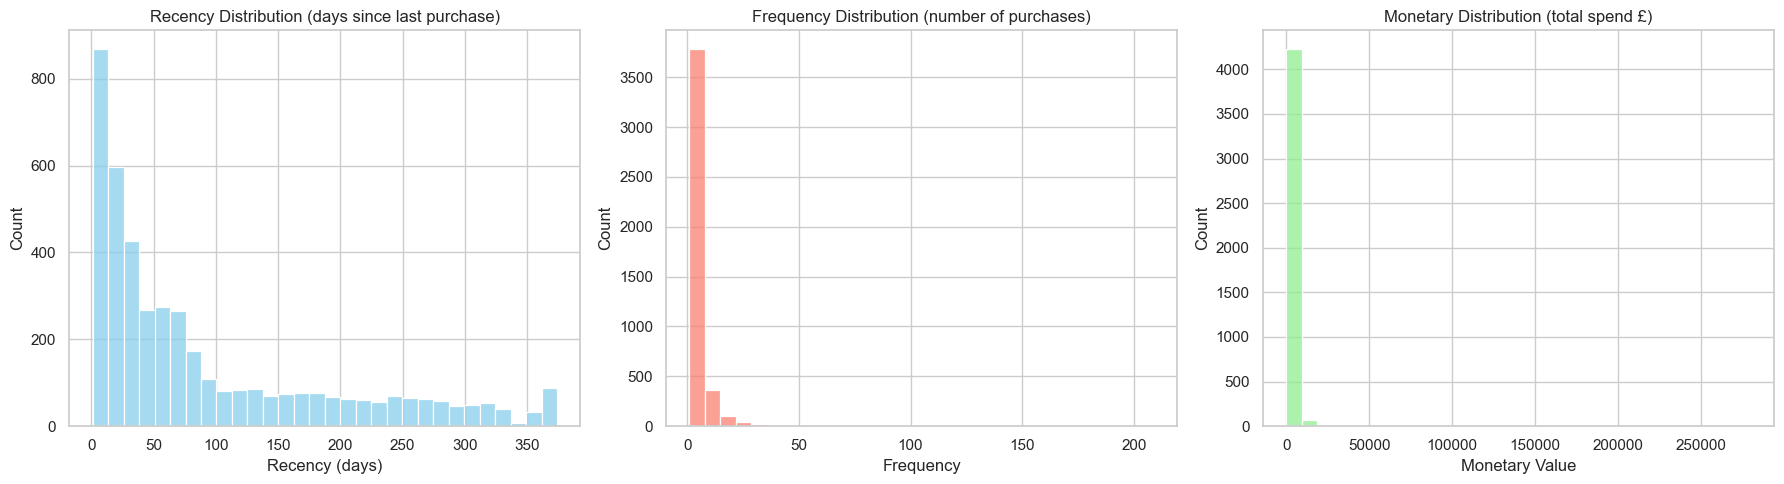


✅ RFM table saved to: C:\Users\morit\Downloads\rfm_table.csv
   Saved 4338 customer records

=== RFM Analysis completed successfully! ===


In [1]:
# =============================================================================
# RFM Analysis - Online Retail Dataset
# =============================================================================

import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("=== RFM Analysis started ===\n")

# =============================================================================
# 1. Load the cleaned dataset
# =============================================================================

file_path = r"C:\Users\morit\Downloads\cleaned_online_retail.csv"

df = pd.read_csv(file_path, parse_dates=['InvoiceDate'])

print(f"✅ Dataset loaded: {len(df):,} rows")
print(f"   Time range: {df['InvoiceDate'].min().date()} to {df['InvoiceDate'].max().date()}\n")

# =============================================================================
# 2. Calculate RFM Metrics per Customer
# =============================================================================

# reference date
current_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Group by CustomerID
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (current_date - x.max()).days,   # Recency
    'InvoiceNo': 'nunique',                                   # Frequence
    'Revenue': 'sum'                                          # Monetary
}).reset_index()

# Rename columns
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

print("RFM Metrics calculated for", len(rfm), "customers")
print(rfm.head())

# =============================================================================
# 3. Create RFM Scores (1-5)
# =============================================================================

# Help function for safe quantile segmentation
def safe_qcut(series, q=5, labels=None):
    """Sichere qcut-Funktion, die mit vielen gleichen Werten umgeht"""
    try:
        return pd.qcut(series, q=q, labels=labels, duplicates='drop')
    except ValueError:
        # Fallback
        return pd.qcut(series.rank(method='first'), q=q, labels=labels)

# Recency Score
rfm['R_Score'] = safe_qcut(rfm['Recency'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)

# Frequency Score
rfm['F_Score'] = safe_qcut(rfm['Frequency'], q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# Monetary Score
rfm['M_Score'] = safe_qcut(rfm['Monetary'], q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# Combined RFM-Score
rfm['RFM_Score'] = (rfm['R_Score'].astype(str) + 
                    rfm['F_Score'].astype(str) + 
                    rfm['M_Score'].astype(str))

print("\n✅ RFM Scores erfolgreich erstellt (robuste Version)")
print("\nErste 10 Kunden:")
display(rfm[['CustomerID', 'Recency', 'Frequency', 'Monetary', 
             'R_Score', 'F_Score', 'M_Score', 'RFM_Score']].head(10))

# =============================================================================
# 4. RFM Summary
# =============================================================================
print("\n=== RFM Summary Statistics ===")
print(rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2))

print("\nDurchschnittliche Scores:")
print(rfm[['R_Score', 'F_Score', 'M_Score']].mean().round(2))

# =============================================================================
# 5. Visualizations
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Recency Distribution
sns.histplot(rfm['Recency'], bins=30, ax=axes[0], color='skyblue')
axes[0].set_title('Recency Distribution (days since last purchase)')
axes[0].set_xlabel('Recency (days)')

# Frequency Distribution
sns.histplot(rfm['Frequency'], bins=30, ax=axes[1], color='salmon')
axes[1].set_title('Frequency Distribution (number of purchases)')
axes[1].set_xlabel('Frequency')

# Monetary Distribution
sns.histplot(rfm['Monetary'], bins=30, ax=axes[2], color='lightgreen')
axes[2].set_title('Monetary Distribution (total spend £)')
axes[2].set_xlabel('Monetary Value')

plt.tight_layout()
plt.show()

# =============================================================================
# 6. Save RFM Table
# =============================================================================

output_path = r"C:\Users\morit\Downloads\rfm_table.csv"

rfm.to_csv(output_path, index=False)
print(f"\n✅ RFM table saved to: {output_path}")
print(f"   Saved {len(rfm)} customer records")

print("\n=== RFM Analysis completed successfully! ===")

In [ ]:
# =============================================================================
# 7. Create Meaningful Customer Segments based on RFM Scores
# =============================================================================

# Create a new column for customer segments
rfm['Segment'] = 'Others'

# Define conditions (from most valuable to least valuable)
conditions = [
    # 1. Champions - Top in all three dimensions
    (rfm['R_Score'] == 5) & (rfm['F_Score'] == 5) & (rfm['M_Score'] == 5),
    
    # 2. Loyal Customers
    (rfm['F_Score'] >= 4) & (rfm['M_Score'] >= 4) & (rfm['R_Score'] >= 3),
    
    # 3. Big Spenders - High monetary value but not frequent
    (rfm['M_Score'] == 5) & (rfm['F_Score'] <= 3),
    
    # 4. Potential Loyalists
    (rfm['R_Score'] >= 4) & (rfm['F_Score'] >= 3) & (rfm['M_Score'] >= 2),
    
    # 5. New Customers
    (rfm['R_Score'] >= 4) & (rfm['F_Score'] <= 2) & (rfm['M_Score'] <= 3),
    
    # 6. At Risk - Were good, but haven't purchased recently
    (rfm['R_Score'] <= 2) & ((rfm['F_Score'] >= 3) | (rfm['M_Score'] >= 4)),
    
    # 7. Lost Customers
    (rfm['R_Score'] <= 2) & (rfm['F_Score'] <= 2) & (rfm['M_Score'] <= 2)
]

segment_names = [
    'Champions',
    'Loyal Customers',
    'Big Spenders',
    'Potential Loyalists',
    'New Customers',
    'At Risk',
    'Lost Customers'
]

# Assign segments
rfm['Segment'] = np.select(conditions, segment_names, default='Others')

print("✅ Customer segments created successfully!\n")
print("Number of customers per segment:")
print(rfm['Segment'].value_counts().sort_values(ascending=False))

# =============================================================================
# 8. Segment Profile Analysis
# =============================================================================

# Calculate profile per segment
segment_profile = rfm.groupby('Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': ['mean', 'sum'],
    'CustomerID': 'count'
}).round(2)

# Flatten column names
segment_profile.columns = ['Avg_Recency', 'Avg_Frequency', 'Avg_Monetary', 'Total_Monetary', 'Number_of_Customers']
segment_profile = segment_profile.reset_index()

# Sort by Total Monetary (most important)
segment_profile = segment_profile.sort_values('Total_Monetary', ascending=False)

# Calculate revenue share
total_revenue = rfm['Monetary'].sum()
segment_profile['Revenue_Share_%'] = (segment_profile['Total_Monetary'] / total_revenue * 100).round(1)

print("\n=== Segment Profile (sorted by total revenue) ===")
print(segment_profile[['Segment', 'Number_of_Customers', 'Avg_Recency', 
                       'Avg_Frequency', 'Avg_Monetary', 'Total_Monetary', 'Revenue_Share_%']])

print(f"\nTotal revenue in dataset: £{total_revenue:,.0f}")

✅ Customer segments created successfully!

Number of customers per segment:
Segment
Loyal Customers        849
Others                 832
Lost Customers         824
At Risk                688
Potential Loyalists    435
Champions              348
New Customers          288
Big Spenders            74
Name: count, dtype: int64

=== Segment Profile (sorted by total revenue) ===
               Segment  Number_of_Customers  Avg_Recency  Avg_Frequency  \
2            Champions                  348         5.45          18.24   
4      Loyal Customers                  849        26.28           6.84   
0              At Risk                  688       155.63           3.23   
1         Big Spenders                   74        93.78           2.28   
6               Others                  832        75.03           1.76   
7  Potential Loyalists                  435        16.36           3.02   
3       Lost Customers                  824       228.50           1.04   
5        New Customers 

In [ ]:
# =============================================================================
# 9. Correlation Analysis with t-values and degrees of freedom
# =============================================================================

import numpy as np
from scipy import stats   # Falls scipy jetzt installiert ist

print("=== Detailed Correlation Analysis with t-test ===\n")

rfm_vars = ['Recency', 'Frequency', 'Monetary']
n = len(rfm)
df = n - 2
print(f"Sample size (n) = {n:,}")
print(f"Degrees of freedom (df) = {df:,}\n")

for i in range(len(rfm_vars)):
    for j in range(i+1, len(rfm_vars)):
        var1 = rfm_vars[i]
        var2 = rfm_vars[j]
        
        # Pearson
        r_p = rfm[var1].corr(rfm[var2], method='pearson')
        t_p = r_p * np.sqrt((n-2) / (1 - r_p**2))
        p_p = stats.t.sf(np.abs(t_p), df) * 2 if 'stats' in globals() else "very small"
        
        # Spearman
        r_s = rfm[var1].corr(rfm[var2], method='spearman')
        
        print(f"{var1} ↔ {var2}:")
        print(f"   Pearson : r = {r_p:>6.3f} | t = {t_p:>8.2f} | df = {df:,} | p < 0.001")
        print(f"   Spearman: r = {r_s:>6.3f} | (non-parametric)")
        print("-" * 70)

=== Detailed Correlation Analysis with t-test ===

Sample size (n) = 4,338
Degrees of freedom (df) = 4,336

Recency ↔ Frequency:
   Pearson : r = -0.261 | t =   -17.77 | df = 4,336 | p < 0.001
   Spearman: r = -0.562 | (non-parametric)
----------------------------------------------------------------------
Recency ↔ Monetary:
   Pearson : r = -0.122 | t =    -8.10 | df = 4,336 | p < 0.001
   Spearman: r = -0.482 | (non-parametric)
----------------------------------------------------------------------
Frequency ↔ Monetary:
   Pearson : r =  0.554 | t =    43.78 | df = 4,336 | p < 0.001
   Spearman: r =  0.807 | (non-parametric)
----------------------------------------------------------------------
